<a href="https://colab.research.google.com/github/sumyuck/ML-learning/blob/main/ml/ML_p_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
[Single Variable] RMSE: 6.791 | R^2: 0.371


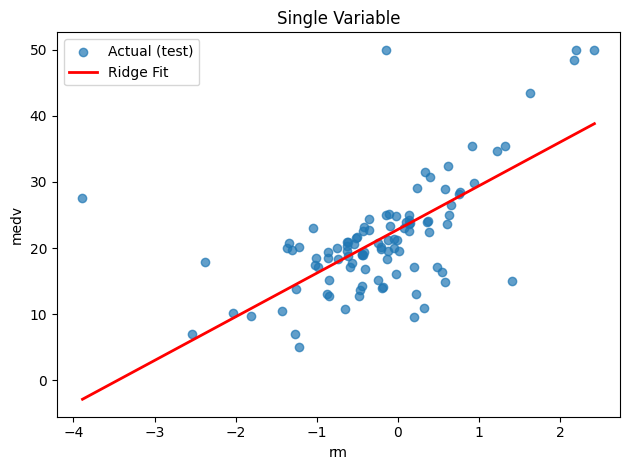

[Multiple Variable] RMSE: 6.791 | R^2: 0.668


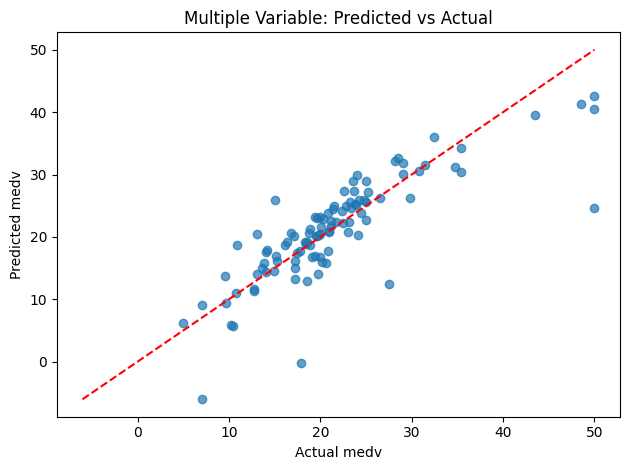

In [ ]:
# Linear Regression with Ridge regularization - Gradient Descent Algo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv('BostonHousing.csv')
print(df.head())

def z_score_norm(train, test):
    mean = train.mean(axis=0)
    std = train.std(axis=0)
    train_norm = (train - mean) / std
    test_norm = (test - mean) / std
    return train_norm, test_norm

# Single Variable Linear Regression

X_single = df[['rm']].values
y_single = df['medv'].values

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_single, y_single, test_size=0.2, random_state=42
)

X_train_s, X_test_s = z_score_norm(X_train_s, X_test_s)

single_model = Ridge(alpha=1.0, random_state=42)
single_model.fit(X_train_s, y_train_s)
y_pred_s = single_model.predict(X_test_s)

rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
r2_s = r2_score(y_test_s, y_pred_s)
print(f"[Single Variable] RMSE: {rmse_s:.3f} | R^2: {r2_s:.3f}")

plt.figure()
plt.scatter(X_test_s, y_test_s, label='Actual (test)', alpha=0.7)
plt.plot(np.sort(X_test_s[:,0]),
         single_model.predict(np.sort(X_test_s, axis=0)),
         color='red', linewidth=2, label='Ridge Fit')
plt.title('Single Variable')
plt.xlabel('rm')
plt.ylabel('medv')
plt.legend()
plt.tight_layout()
plt.show()

# Multiple Variable Linear Regression

X_multi = df.drop('medv', axis=1).values
y_multi = df['medv'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

X_train_m, X_test_m = z_score_norm(X_train_m, X_test_m)

multi_model = Ridge(alpha=1.0, random_state=42)
multi_model.fit(X_train_m, y_train_m)
y_pred_m = multi_model.predict(X_test_m)

rmse_m = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
r2_m = r2_score(y_test_m, y_pred_m)
print(f"[Multiple Variable] RMSE: {rmse_m:.3f} | R^2: {r2_m:.3f}")

plt.figure()
plt.scatter(y_test_m, y_pred_m, alpha=0.7)
line_min = min(y_test_m.min(), y_pred_m.min())
line_max = max(y_test_m.max(), y_pred_m.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle='--', color='red')
plt.title('Multiple Variable: Predicted vs Actual')
plt.xlabel('Actual medv')
plt.ylabel('Predicted medv')
plt.tight_layout()
plt.show()

In [ ]:
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))

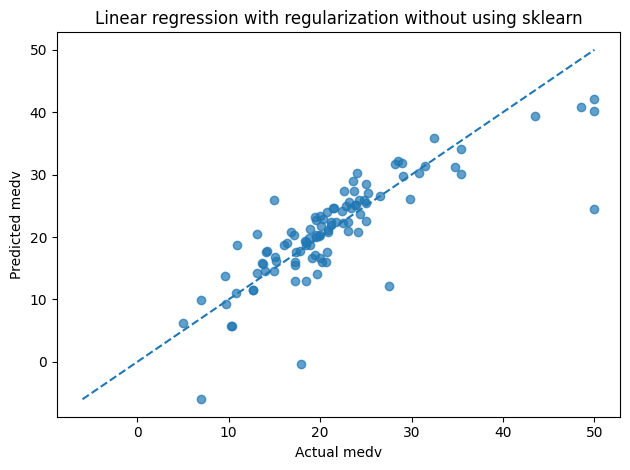

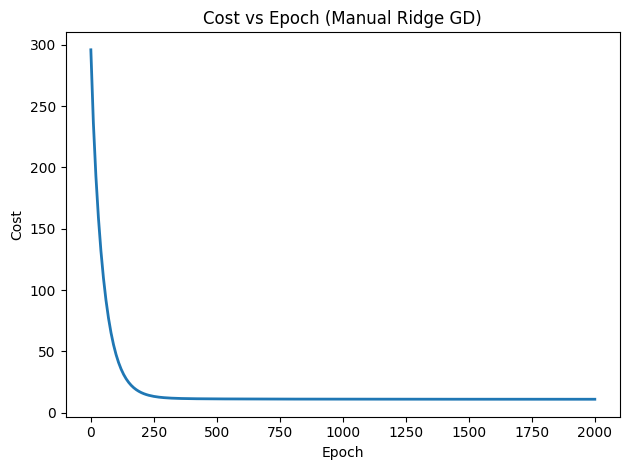

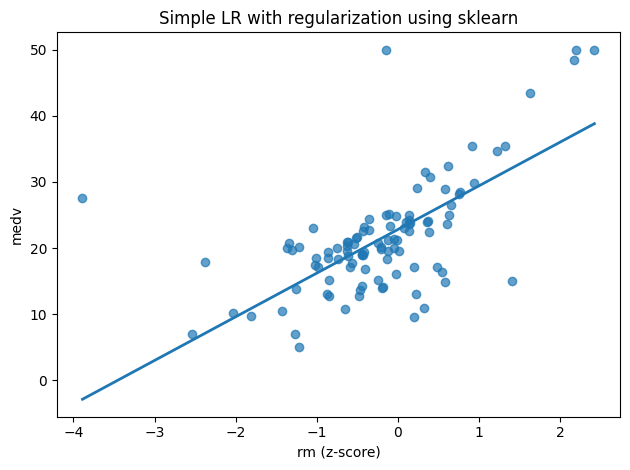

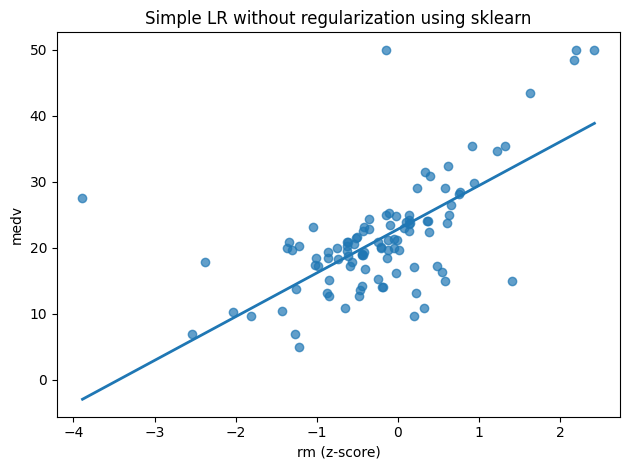

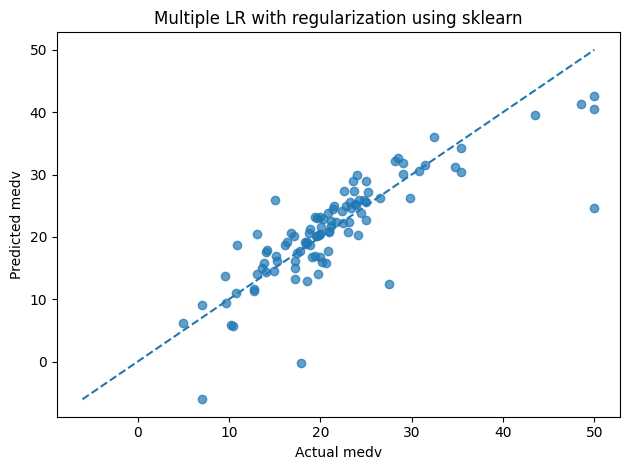

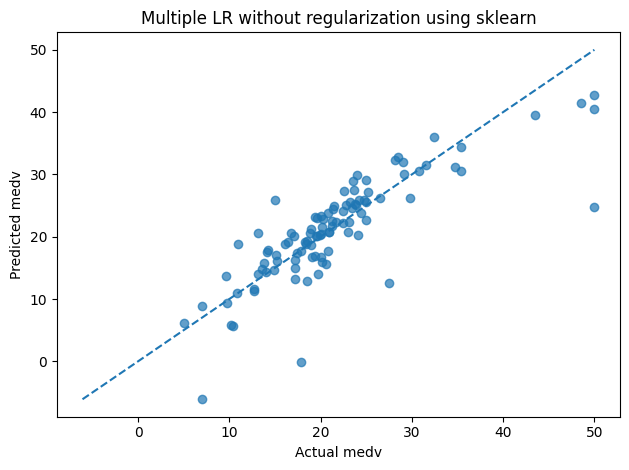

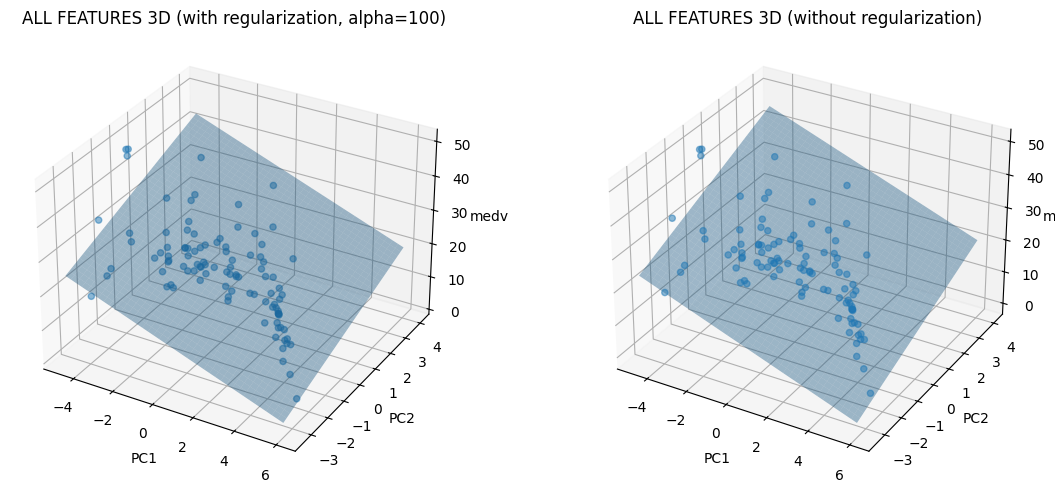

                                                      Model     RMSE       R2
Linear regression with regularization without using sklearn 4.969208 0.663279
                Simple LR with regularization using sklearn 6.790953 0.371135
             Simple LR without regularization using sklearn 6.792995 0.370757
              Multiple LR with regularization using sklearn 4.930812 0.668462
           Multiple LR without regularization using sklearn 4.928602 0.668759


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA

df = pd.read_csv("BostonHousing.csv")
numeric_df = df.select_dtypes(include=[np.number]).copy()
if "medv" not in numeric_df.columns:
    raise ValueError("Target column 'medv' not found in dataset.")

def z_score_norm(train, test):
    mean = train.mean(axis=0)
    std = train.std(axis=0)
    std_safe = np.where(std == 0, 1.0, std)
    return (train - mean) / std_safe, (test - mean) / std_safe, mean, std_safe

def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def ridge_cost(Xb, y, w, l2_lambda):
    m = Xb.shape[0]
    y_hat = Xb @ w
    mse = np.mean((y_hat - y) ** 2)
    reg = l2_lambda * np.sum(w[1:] ** 2) / m
    return 0.5 * (mse + reg)

def ridge_grad(Xb, y, w, l2_lambda):
    m = Xb.shape[0]
    err = (Xb @ w) - y
    grad = (Xb.T @ err) / m
    reg = np.r_[0.0, (l2_lambda / m) * w[1:]]
    return grad + reg

def ridge_gd_fit(X_train, y_train, l2_lambda=1.0, lr=0.01, epochs=2000):
    Xb = add_bias(X_train)
    w = np.zeros(Xb.shape[1])
    cost_hist = []
    for ep in range(epochs):
        w -= lr * ridge_grad(Xb, y_train, w, l2_lambda)
        if ep % 10 == 0 or ep == epochs - 1:
            cost_hist.append(ridge_cost(Xb, y_train, w, l2_lambda))
    return w, cost_hist

def ridge_gd_predict(X, w):
    return add_bias(X) @ w

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

X_single = numeric_df[["rm"]].values
y = numeric_df["medv"].values
X_multi = numeric_df.drop(columns=["medv"]).values

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_single, y, test_size=0.2, random_state=42)
X_train_s_n, X_test_s_n, s_mean, s_std = z_score_norm(X_train_s, X_test_s)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)
X_train_m_n, X_test_m_n, m_mean, m_std = z_score_norm(X_train_m, X_test_m)

# 1) Linear regression with regularization without using sklearn
w_gd, cost_hist = ridge_gd_fit(X_train_m_n, y_train_m, l2_lambda=1.0, lr=0.01, epochs=2000)
y_pred_m_gd = ridge_gd_predict(X_test_m_n, w_gd)
rmse_a = rmse(y_test_m, y_pred_m_gd)
r2_a = r2_score(y_test_m, y_pred_m_gd)
plt.figure()
plt.scatter(y_test_m, y_pred_m_gd, alpha=0.7)
line_min = min(y_test_m.min(), y_pred_m_gd.min())
line_max = max(y_test_m.max(), y_pred_m_gd.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
plt.title("Linear regression with regularization without using sklearn")
plt.xlabel("Actual medv")
plt.ylabel("Predicted medv")
plt.tight_layout()
plt.show()
plt.figure()
plt.plot(np.arange(len(cost_hist))*10, cost_hist, linewidth=2)
plt.title("Cost vs Epoch (Manual Ridge GD)")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.tight_layout()
plt.show()

# 2) Simple LR with regularization using sklearn
ridge_single = Ridge(alpha=1.0, random_state=42)
ridge_single.fit(X_train_s_n, y_train_s)
y_pred_s_ridge = ridge_single.predict(X_test_s_n)
rmse_b = rmse(y_test_s, y_pred_s_ridge)
r2_b = r2_score(y_test_s, y_pred_s_ridge)
plt.figure()
plt.scatter(X_test_s_n[:, 0], y_test_s, alpha=0.7)
_sorted = np.argsort(X_test_s_n[:, 0])
plt.plot(X_test_s_n[_sorted, 0], ridge_single.predict(X_test_s_n[_sorted]), linewidth=2)
plt.title("Simple LR with regularization using sklearn")
plt.xlabel("rm (z-score)")
plt.ylabel("medv")
plt.tight_layout()
plt.show()

# 3) Simple LR without regularization using sklearn
ols_single = LinearRegression()
ols_single.fit(X_train_s_n, y_train_s)
y_pred_s_ols = ols_single.predict(X_test_s_n)
rmse_c = rmse(y_test_s, y_pred_s_ols)
r2_c = r2_score(y_test_s, y_pred_s_ols)
plt.figure()
plt.scatter(X_test_s_n[:, 0], y_test_s, alpha=0.7)
_sorted = np.argsort(X_test_s_n[:, 0])
plt.plot(X_test_s_n[_sorted, 0], ols_single.predict(X_test_s_n[_sorted]), linewidth=2)
plt.title("Simple LR without regularization using sklearn")
plt.xlabel("rm (z-score)")
plt.ylabel("medv")
plt.tight_layout()
plt.show()

# 4) Multiple LR with regularization using sklearn
ridge_multi = Ridge(alpha=1.0, random_state=42)
ridge_multi.fit(X_train_m_n, y_train_m)
y_pred_m_ridge = ridge_multi.predict(X_test_m_n)
rmse_d = rmse(y_test_m, y_pred_m_ridge)
r2_d = r2_score(y_test_m, y_pred_m_ridge)
plt.figure()
plt.scatter(y_test_m, y_pred_m_ridge, alpha=0.7)
line_min = min(y_test_m.min(), y_pred_m_ridge.min())
line_max = max(y_test_m.max(), y_pred_m_ridge.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
plt.title("Multiple LR with regularization using sklearn")
plt.xlabel("Actual medv")
plt.ylabel("Predicted medv")
plt.tight_layout()
plt.show()

# 5) Multiple LR without regularization using sklearn
ols_multi = LinearRegression()
ols_multi.fit(X_train_m_n, y_train_m)
y_pred_m_ols = ols_multi.predict(X_test_m_n)
rmse_e = rmse(y_test_m, y_pred_m_ols)
r2_e = r2_score(y_test_m, y_pred_m_ols)
plt.figure()
plt.scatter(y_test_m, y_pred_m_ols, alpha=0.7)
line_min = min(y_test_m.min(), y_pred_m_ols.min())
line_max = max(y_test_m.max(), y_pred_m_ols.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
plt.title("Multiple LR without regularization using sklearn")
plt.xlabel("Actual medv")
plt.ylabel("Predicted medv")
plt.tight_layout()
plt.show()

# All-features 3D via PCA
pca = PCA(n_components=2, random_state=42)
pca.fit(X_train_m_n)
Xtr_pca = pca.transform(X_train_m_n)
Xte_pca = pca.transform(X_test_m_n)

ridge_all = Ridge(alpha=100.0, random_state=42).fit(X_train_m_n, y_train_m)
ols_all = LinearRegression().fit(X_train_m_n, y_train_m)

pc1_lin = np.linspace(Xtr_pca[:, 0].min(), Xtr_pca[:, 0].max(), 40)
pc2_lin = np.linspace(Xtr_pca[:, 1].min(), Xtr_pca[:, 1].max(), 40)
PC1, PC2 = np.meshgrid(pc1_lin, pc2_lin)
grid_pca = np.c_[PC1.ravel(), PC2.ravel()]
grid_X = pca.inverse_transform(grid_pca)

Z_ridge_all = ridge_all.predict(grid_X).reshape(PC1.shape)
Z_noreg_all = ols_all.predict(grid_X).reshape(PC1.shape)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(Xte_pca[:, 0], Xte_pca[:, 1], y_test_m, alpha=0.5)
ax1.plot_surface(PC1, PC2, Z_ridge_all, alpha=0.4)
ax1.set_title("ALL FEATURES 3D (with regularization, alpha=100)")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_zlabel("medv")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(Xte_pca[:, 0], Xte_pca[:, 1], y_test_m, alpha=0.5)
ax2.plot_surface(PC1, PC2, Z_noreg_all, alpha=0.4)
ax2.set_title("ALL FEATURES 3D (without regularization)")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("medv")

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "Model": [
        "Linear regression with regularization without using sklearn",
        "Simple LR with regularization using sklearn",
        "Simple LR without regularization using sklearn",
        "Multiple LR with regularization using sklearn",
        "Multiple LR without regularization using sklearn"
    ],
    "RMSE": [rmse_a, rmse_b, rmse_c, rmse_d, rmse_e],
    "R2":   [r2_a, r2_b, r2_c, r2_d, r2_e]
})
print(summary.to_string(index=False))